# Mini Project 3 — NIR Biomass Moisture Characterisation


# Data Exploration & Pre-processing

## 0. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import EllipticEnvelope

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
RANDOM_STATE = 42

## 1. Load the Dataset

In [2]:
df_raw = pd.read_excel('NIR_Data.xlsx')

sample_ids  = df_raw['Sample ID']
moisture    = df_raw['Moisture'].values
wavenumbers = df_raw.columns[2:-1].astype(float).values
spectra_raw = df_raw.iloc[:, 2:-1].values

sample_base = sample_ids.str.rsplit('.', n=1).str[0].values

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"  Total scans (rows)        : {spectra_raw.shape[0]}")
print(f"  Spectral variables        : {spectra_raw.shape[1]}")
print(f"  Unique physical samples   : {len(np.unique(sample_base))}")
print(f"  Wavenumber range          : {wavenumbers.min():.1f} – {wavenumbers.max():.1f} cm⁻¹")
print(f"  Corresponding wavelength  : {1e7/wavenumbers.max():.0f} – {1e7/wavenumbers.min():.0f} nm")
print(f"  Moisture range            : {moisture.min():.2f} – {moisture.max():.2f} %")
print(f"  Moisture mean ± std       : {moisture.mean():.2f} ± {moisture.std():.2f} %")
print(f"  Missing values            : {np.isnan(spectra_raw).sum()}")

DATASET OVERVIEW
  Total scans (rows)        : 773
  Spectral variables        : 1037
  Unique physical samples   : 126
  Wavenumber range          : 3996.2 – 11988.5 cm⁻¹
  Corresponding wavelength  : 834 – 2502 nm
  Moisture range            : 17.98 – 73.07 %
  Moisture mean ± std       : 45.92 ± 14.43 %
  Missing values            : 0


## 2. Exploratory Data Analysis (EDA)

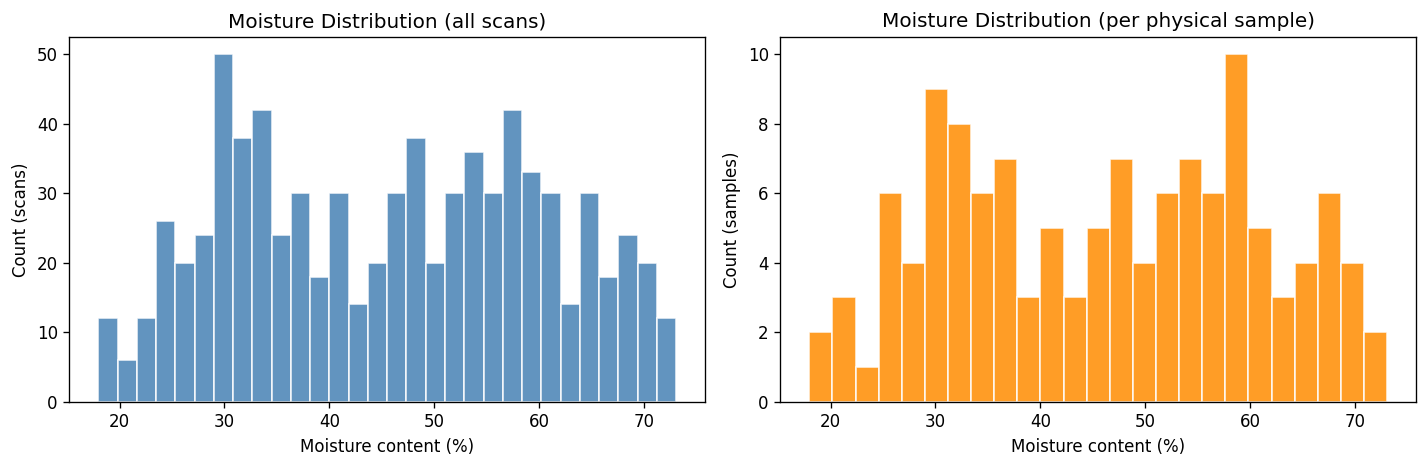

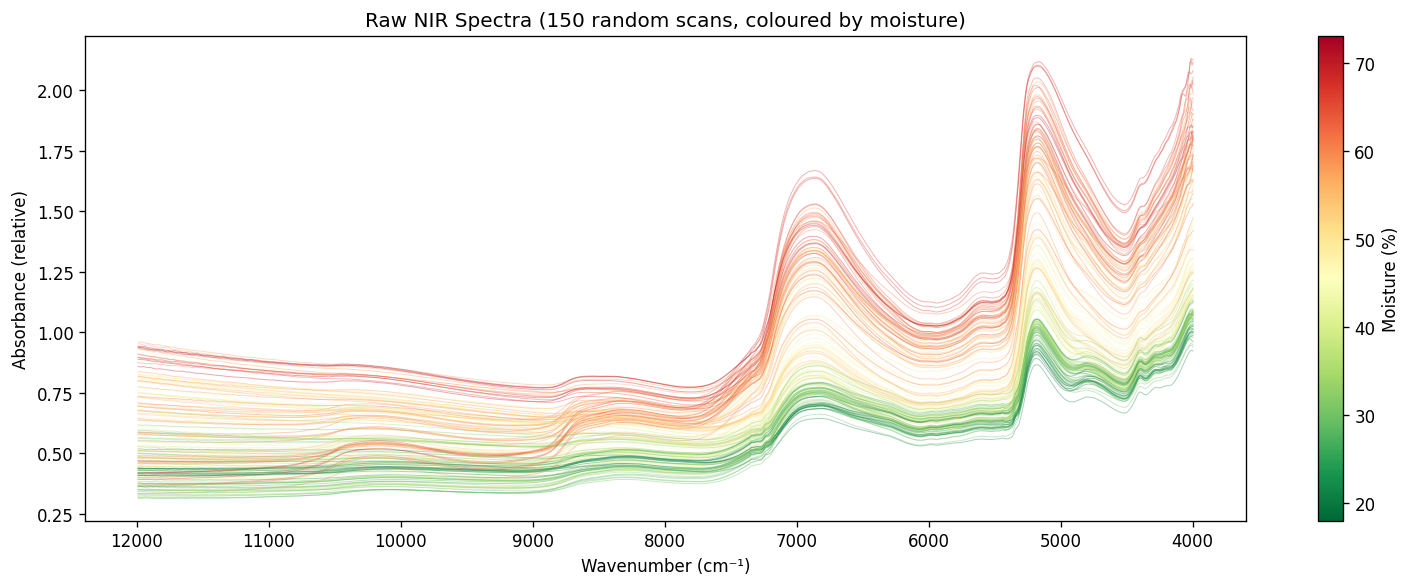

Figures 1 & 2 saved.


In [3]:
rng = np.random.default_rng(RANDOM_STATE)

# ── 2.1  Moisture distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(moisture, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Moisture content (%)'); axes[0].set_ylabel('Count (scans)')
axes[0].set_title('Moisture Distribution (all scans)')

moisture_per_sample = np.array([moisture[sample_base == s].mean()
                                 for s in np.unique(sample_base)])
axes[1].hist(moisture_per_sample, bins=25, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Moisture content (%)'); axes[1].set_ylabel('Count (samples)')
axes[1].set_title('Moisture Distribution (per physical sample)')
plt.tight_layout(); plt.savefig('fig1_moisture_distribution.png', bbox_inches='tight'); plt.show()

# ── 2.2  Raw spectra coloured by moisture ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
idx_plot = rng.choice(len(spectra_raw), size=150, replace=False)
for i in idx_plot:
    color = plt.cm.RdYlGn_r((moisture[i] - moisture.min()) / (moisture.max() - moisture.min()))
    ax.plot(wavenumbers, spectra_raw[i], color=color, alpha=0.35, linewidth=0.6)
sm = plt.cm.ScalarMappable(cmap='RdYlGn_r',
                            norm=plt.Normalize(moisture.min(), moisture.max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Moisture (%)')
ax.set_xlabel('Wavenumber (cm⁻¹)'); ax.set_ylabel('Absorbance (relative)')
ax.set_title('Raw NIR Spectra (150 random scans, coloured by moisture)')
ax.invert_xaxis()
plt.tight_layout(); plt.savefig('fig2_raw_spectra.png', bbox_inches='tight'); plt.show()
print("Figures 1 & 2 saved.")

## 3. Outlier Detection

Explained variance by first 10 PCs:
  PC1: 76.79%  (cumulative: 76.79%)
  PC2: 22.81%  (cumulative: 99.60%)
  PC3: 0.32%  (cumulative: 99.93%)
  PC4: 0.04%  (cumulative: 99.97%)
  PC5: 0.02%  (cumulative: 99.98%)
  PC6: 0.01%  (cumulative: 99.99%)
  PC7: 0.00%  (cumulative: 99.99%)
  PC8: 0.00%  (cumulative: 100.00%)
  PC9: 0.00%  (cumulative: 100.00%)
  PC10: 0.00%  (cumulative: 100.00%)

Outlier detection (97.5th-percentile cutoff)
  Hotelling T² outliers : 20 scans
  Q-residual outliers   : 20 scans
  Combined (T² OR Q)    : 39 scans (5.0%)


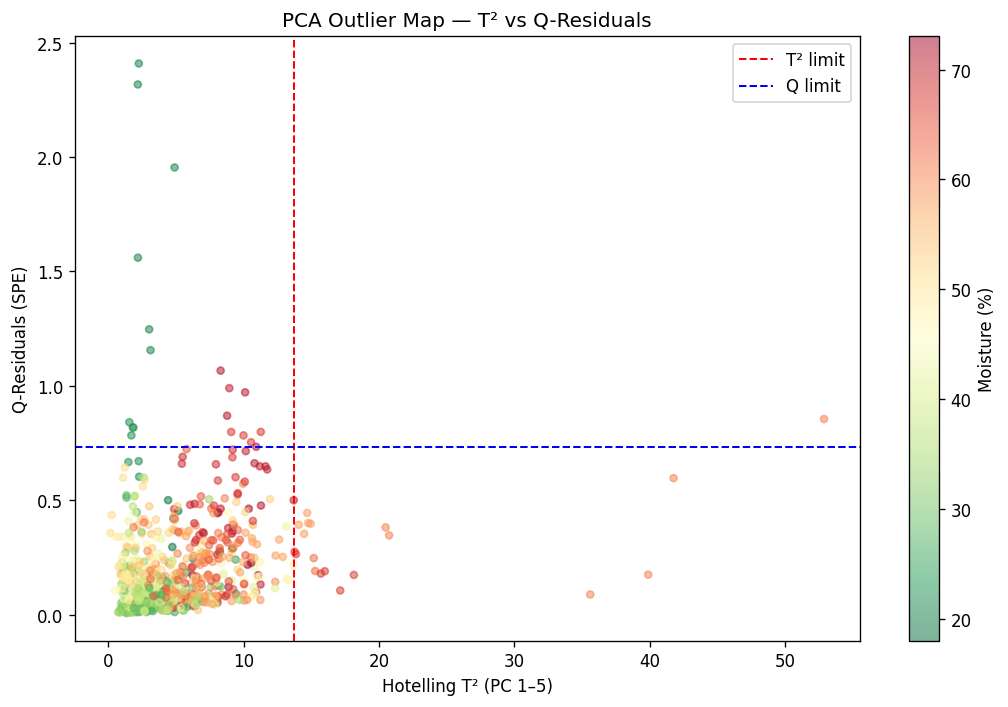

Figure 4 saved.


In [4]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(spectra_raw)
pca_od   = PCA(n_components=10, random_state=RANDOM_STATE)
scores   = pca_od.fit_transform(X_scaled)

print("Explained variance by first 10 PCs:")
for i, ev in enumerate(pca_od.explained_variance_ratio_):
    print(f"  PC{i+1}: {ev*100:.2f}%  (cumulative: {pca_od.explained_variance_ratio_[:i+1].sum()*100:.2f}%)")

# Hotelling T² (first 5 PCs)
n_pcs = 5
S = scores[:, :n_pcs]
cov_inv = np.linalg.pinv(np.cov(S.T))
T2 = np.array([s @ cov_inv @ s for s in S])
T2_threshold = np.percentile(T2, 97.5)

# Q-residuals (SPE)
X_reconstructed = scores[:, :n_pcs] @ pca_od.components_[:n_pcs]
Q_residuals  = np.sum((X_scaled - X_reconstructed) ** 2, axis=1)
Q_threshold  = np.percentile(Q_residuals, 97.5)

outlier_T2  = T2 > T2_threshold
outlier_Q   = Q_residuals > Q_threshold
outlier_any = outlier_T2 | outlier_Q

print(f"\nOutlier detection (97.5th-percentile cutoff)")
print(f"  Hotelling T² outliers : {outlier_T2.sum()} scans")
print(f"  Q-residual outliers   : {outlier_Q.sum()} scans")
print(f"  Combined (T² OR Q)    : {outlier_any.sum()} scans ({outlier_any.mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(T2, Q_residuals, c=moisture, cmap='RdYlGn_r', alpha=0.5, s=18,
                     vmin=moisture.min(), vmax=moisture.max())
ax.axvline(T2_threshold, color='red',  linestyle='--', linewidth=1.2, label='T² limit')
ax.axhline(Q_threshold,  color='blue', linestyle='--', linewidth=1.2, label='Q limit')
plt.colorbar(scatter, ax=ax, label='Moisture (%)')
ax.set_xlabel("Hotelling T² (PC 1–5)"); ax.set_ylabel("Q-Residuals (SPE)")
ax.set_title("PCA Outlier Map — T² vs Q-Residuals"); ax.legend()
plt.tight_layout(); plt.savefig('fig4_outlier_T2_Q.png', bbox_inches='tight'); plt.show()
print("Figure 4 saved.")

## 4. Replicate Averaging

In [5]:
unique_samples = np.unique(sample_base)
spectra_avg  = np.array([spectra_raw[sample_base == s].mean(axis=0) for s in unique_samples])
moisture_avg = np.array([moisture[sample_base == s].mean()           for s in unique_samples])

print(f"After replicate averaging:")
print(f"  Rows (physical samples): {spectra_avg.shape[0]}")
print(f"  Spectral columns       : {spectra_avg.shape[1]}")

After replicate averaging:
  Rows (physical samples): 126
  Spectral columns       : 1037


## 5. Spectral Pre-processing Functions

In [6]:
def snv(X):
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1,  keepdims=True)
    return (X - mean) / (std + 1e-12)

def msc(X, ref=None):
    if ref is None:
        ref = X.mean(axis=0)
    X_msc = np.zeros_like(X)
    for i, spec in enumerate(X):
        coef = np.polyfit(ref, spec, 1)
        X_msc[i] = (spec - coef[1]) / coef[0]
    return X_msc, ref

def savitzky_golay(X, window=11, polyorder=2, deriv=0):
    return savgol_filter(X, window_length=window, polyorder=polyorder,
                         deriv=deriv, axis=1)

## 6. Apply & Compare Pre-processing Techniques

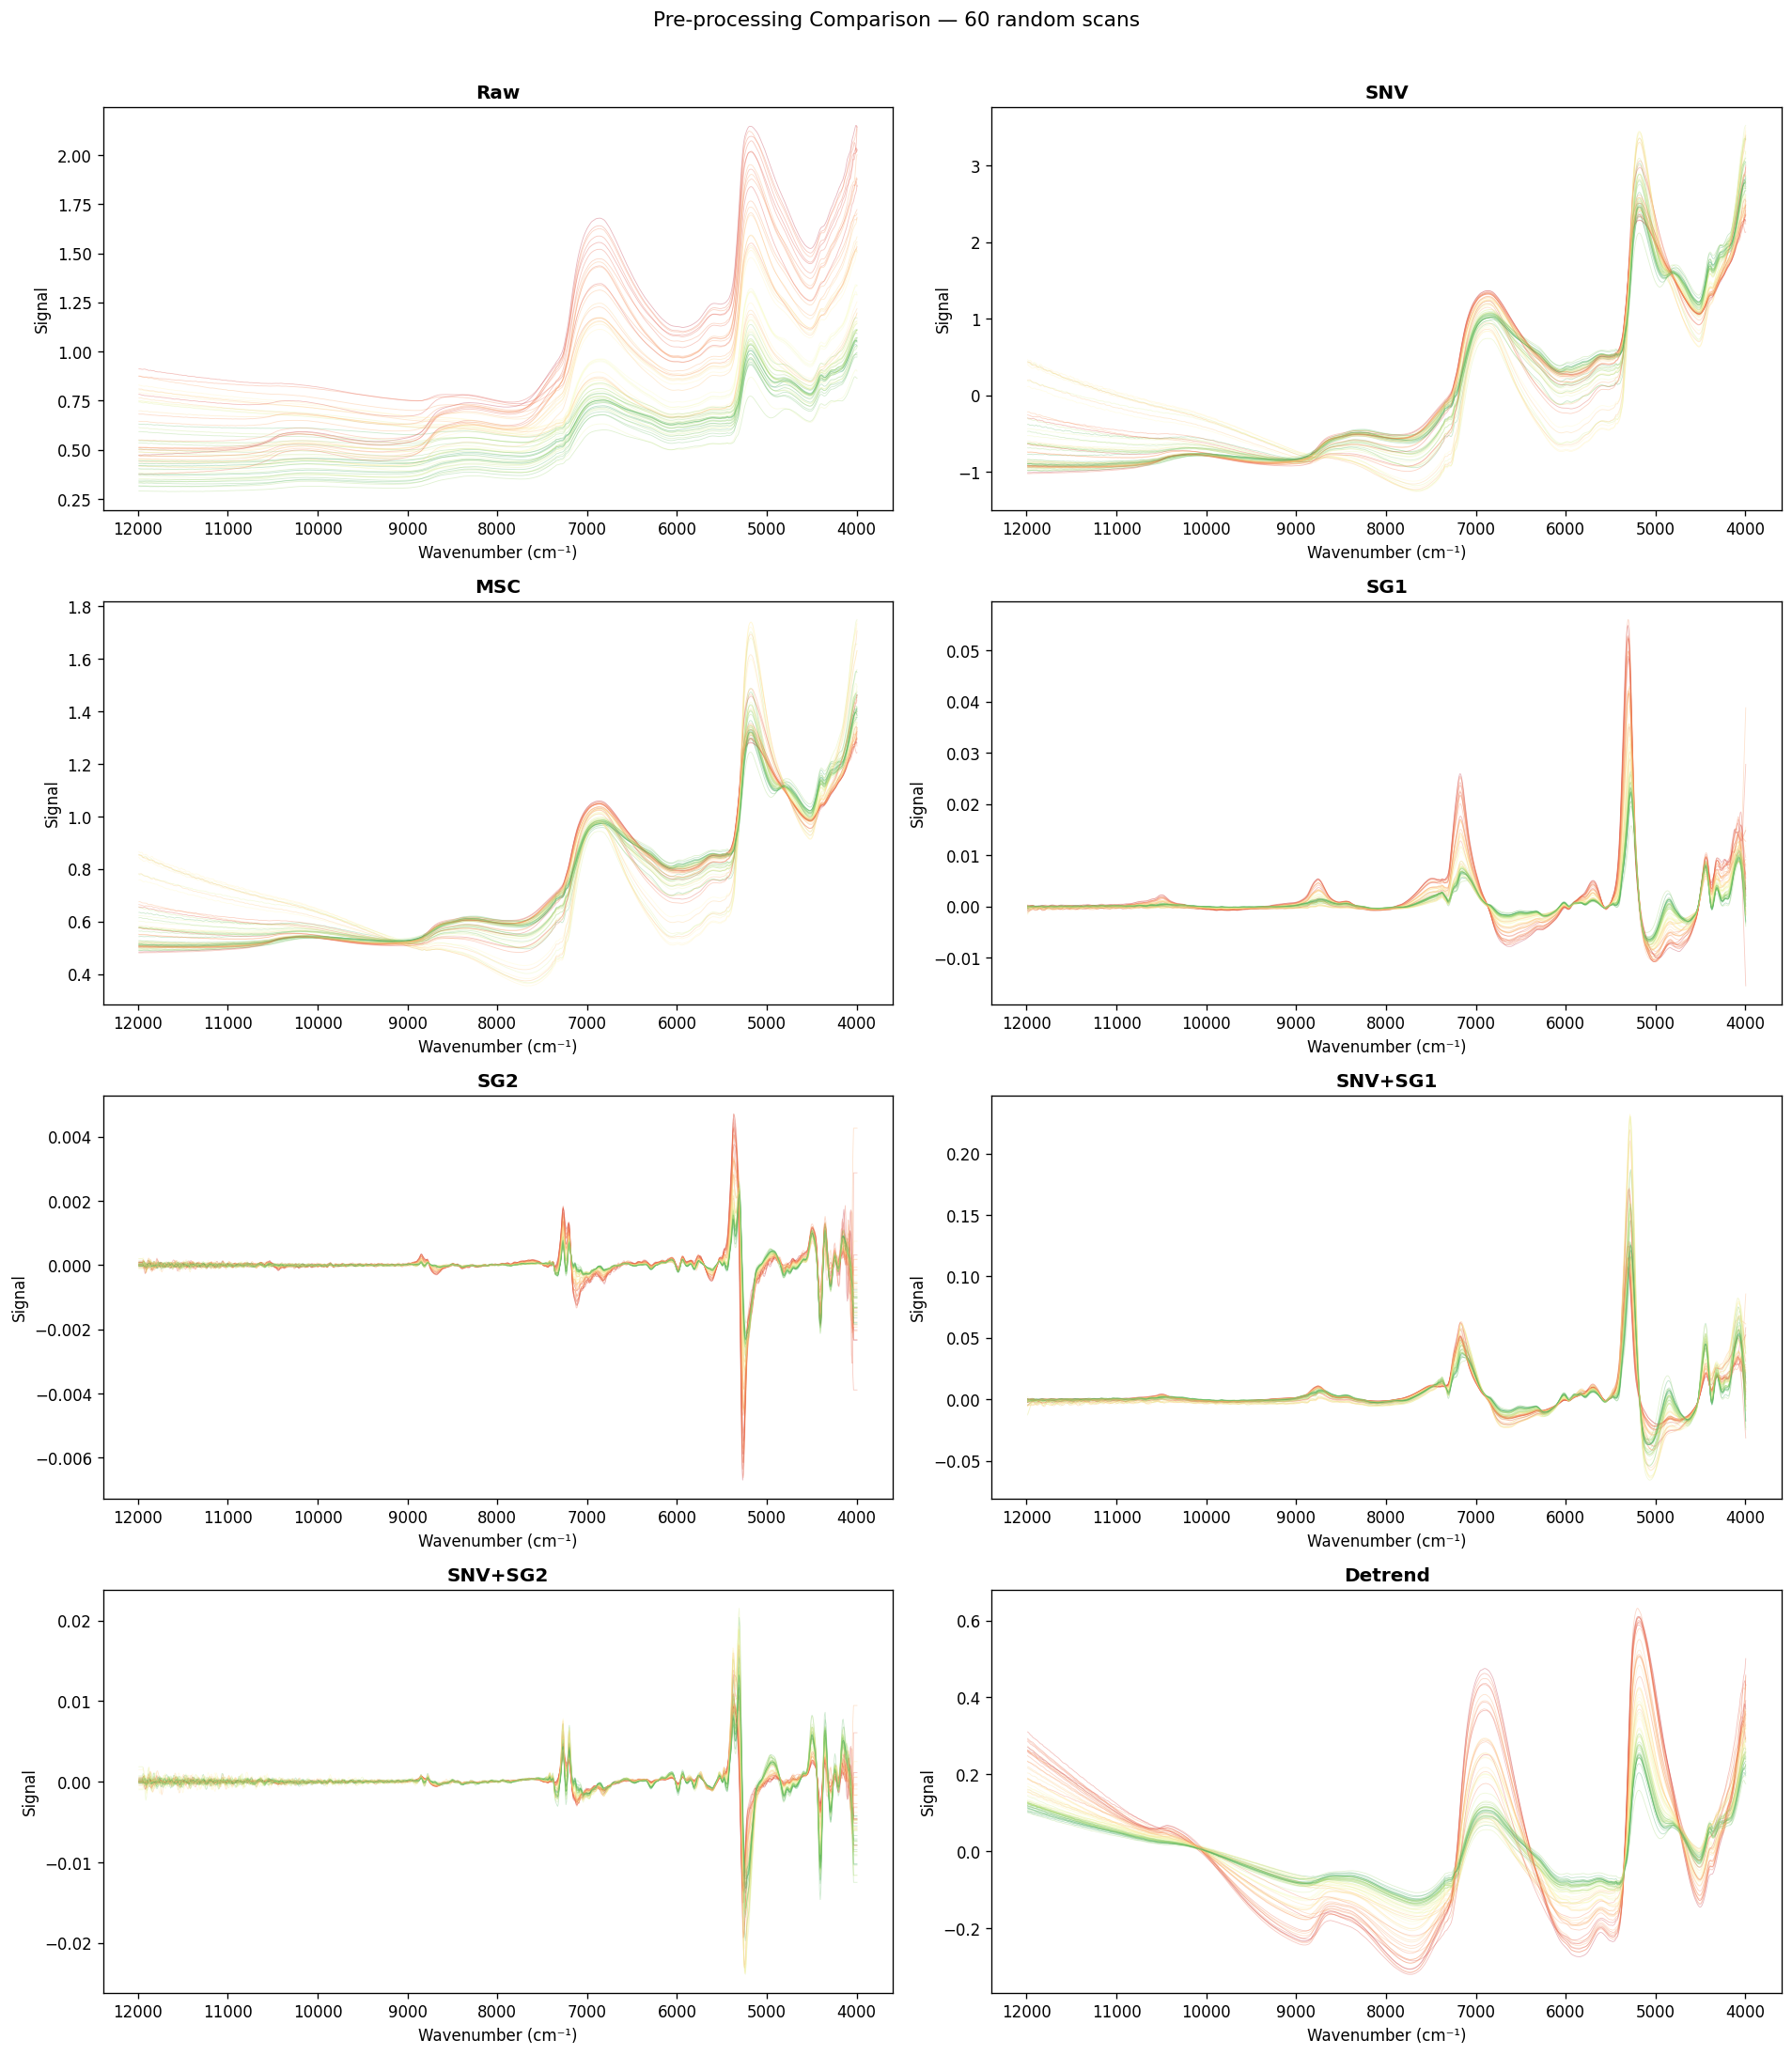

Figure 6 saved.


In [7]:
X = spectra_raw.copy()
X_snv          = snv(X)
X_msc, ref_msc = msc(X)
X_sg1          = savitzky_golay(X, window=11, polyorder=2, deriv=1)
X_sg2          = savitzky_golay(X, window=11, polyorder=2, deriv=2)
X_snv_sg1      = savitzky_golay(snv(X), window=11, polyorder=2, deriv=1)
X_snv_sg2      = savitzky_golay(snv(X), window=11, polyorder=2, deriv=2)
_t = np.arange(X.shape[1])
X_detrend      = np.array([x - np.polyval(np.polyfit(_t, x, 1), _t) for x in X])

preprocessed = {
    'Raw': X, 'SNV': X_snv, 'MSC': X_msc, 'SG1': X_sg1,
    'SG2': X_sg2, 'SNV+SG1': X_snv_sg1, 'SNV+SG2': X_snv_sg2, 'Detrend': X_detrend,
}

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()
idx_show = rng.choice(len(X), size=60, replace=False)
for ax, (name, Xp) in zip(axes, preprocessed.items()):
    for i in idx_show:
        color = plt.cm.RdYlGn_r((moisture[i] - moisture.min()) / (moisture.max() - moisture.min()))
        ax.plot(wavenumbers, Xp[i], color=color, alpha=0.3, linewidth=0.5)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Wavenumber (cm⁻¹)'); ax.set_ylabel('Signal'); ax.invert_xaxis()
plt.suptitle('Pre-processing Comparison — 60 random scans', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig6_preprocessing_comparison.png', bbox_inches='tight'); plt.show()
print("Figure 6 saved.")

## 7. Pre-processing Selection by Grouped CV RMSECV


PRE-PROCESSING SELECTION  —  grouped CV RMSECV (PLSR, 10-fold)
  Method         RMSECV (%)   Best LV
  -----------------------------------
  MSC                2.2016        10
  SNV                2.2221        12
  SNV+SG1            2.3762         8
  SNV+SG2            2.6427         6
  Raw                2.6663        14
  Detrend            2.7437        12
  SG1                2.9805         9
  SG2                3.0433         7

  → Best pre-processing by grouped CV RMSECV : MSC
    RMSECV = 2.2016%  (PLSR LV = 10)


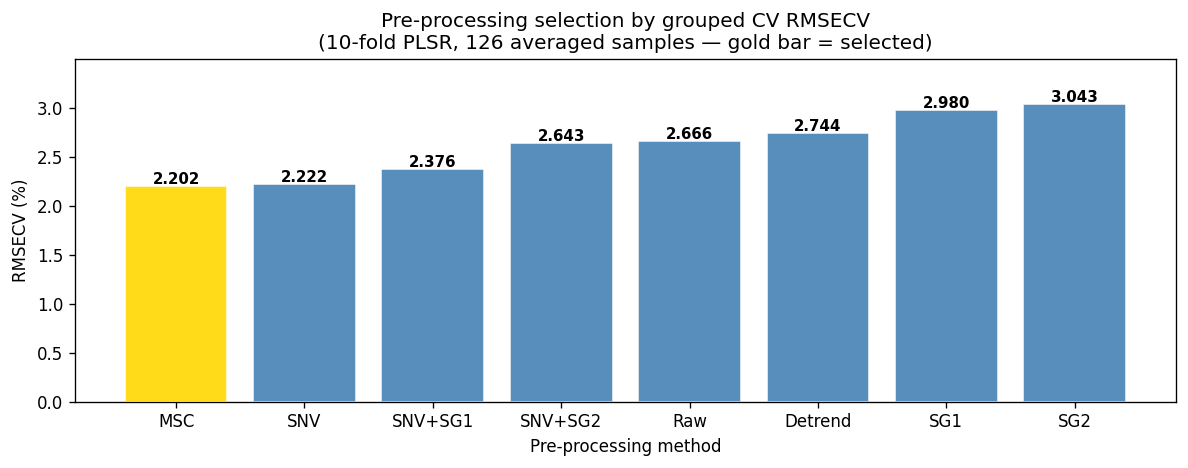

Pre-processing CV selection plot saved.


In [8]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error

# ── Replicate-average all pre-processed versions ──────────────────────────
pp_avg = {}
for name, Xp in preprocessed.items():
    pp_avg[name] = np.array([Xp[sample_base == s].mean(axis=0)
                              for s in unique_samples])
y_avg  = np.array([moisture[sample_base == s].mean() for s in unique_samples])
groups = np.arange(len(y_avg))
gkf    = GroupKFold(n_splits=10)

def plsr_rmsecv(X, y, max_lv=20):
    best_r, best_lv = np.inf, 1
    for n_lv in range(1, max_lv + 1):
        pls = PLSRegression(n_components=n_lv, scale=False)
        yc  = np.zeros_like(y)
        for tr, te in gkf.split(X, y, groups):
            pls.fit(X[tr], y[tr])
            yc[te] = pls.predict(X[te]).ravel()
        r = np.sqrt(mean_squared_error(y, yc))
        if r < best_r:
            best_r, best_lv = r, n_lv
    return best_r, best_lv

print('=' * 60)
print('PRE-PROCESSING SELECTION  —  grouped CV RMSECV (PLSR, 10-fold)')
print('=' * 60)
print(f"  {'Method':<12}  {'RMSECV (%)':>11}  {'Best LV':>8}")
print(f"  {'-'*35}")

cv_results = {}
for name, Xa in pp_avg.items():
    r, lv = plsr_rmsecv(Xa, y_avg)
    cv_results[name] = {'rmsecv': r, 'lv': lv}

for name, res in sorted(cv_results.items(), key=lambda x: x[1]['rmsecv']):
    print(f"  {name:<12}  {res['rmsecv']:>11.4f}  {res['lv']:>8}")

best_pp = min(cv_results, key=lambda k: cv_results[k]['rmsecv'])
print(f"\n  → Best pre-processing by grouped CV RMSECV : {best_pp}")
print(f"    RMSECV = {cv_results[best_pp]['rmsecv']:.4f}%  "
      f"(PLSR LV = {cv_results[best_pp]['lv']})")

# ── Bar chart of RMSECV per method ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
sorted_methods = sorted(cv_results, key=lambda k: cv_results[k]['rmsecv'])
rmsecv_vals    = [cv_results[k]['rmsecv'] for k in sorted_methods]
bar_colors     = ['gold' if k == best_pp else 'steelblue' for k in sorted_methods]
bars = ax.bar(sorted_methods, rmsecv_vals, color=bar_colors,
              edgecolor='white', alpha=0.9)
for bar, val in zip(bars, rmsecv_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('RMSECV (%)'); ax.set_xlabel('Pre-processing method')
ax.set_title('Pre-processing selection by grouped CV RMSECV\n'
             '(10-fold PLSR, 126 averaged samples — gold bar = selected)')
ax.set_ylim(0, max(rmsecv_vals) * 1.15)
plt.tight_layout()
plt.savefig('fig_preprocessing_cv_selection.png', bbox_inches='tight')
plt.show()
print('Pre-processing CV selection plot saved.')


## 8. Spectral Region Analysis

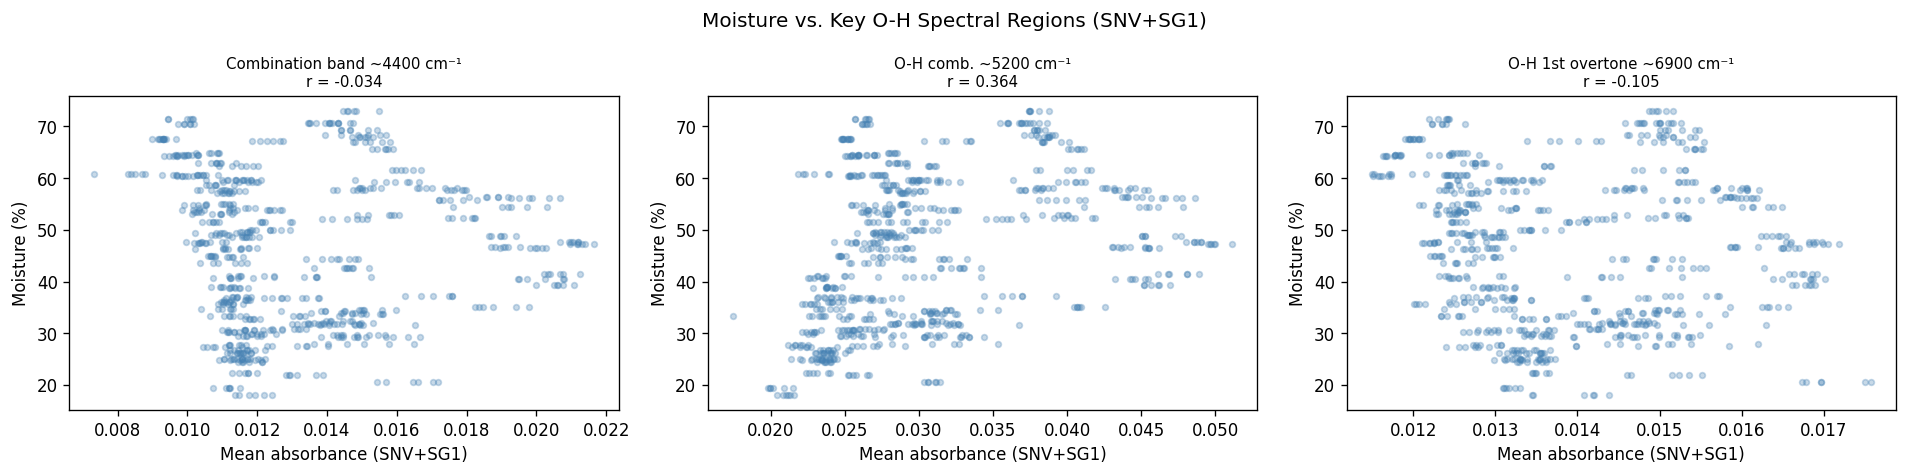

Figure 8 saved.


In [9]:
regions = {
    'Combination band ~4400 cm⁻¹':   (4200, 4600),
    'O-H comb. ~5200 cm⁻¹':          (5000, 5400),
    'O-H 1st overtone ~6900 cm⁻¹':   (6700, 7200),
}
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (label, (lo, hi)) in zip(axes, regions.items()):
    mask = (wavenumbers >= lo) & (wavenumbers <= hi)
    region_mean = X_snv_sg1[:, mask].mean(axis=1)
    ax.scatter(region_mean, moisture, alpha=0.3, s=12, c='steelblue')
    r = np.corrcoef(region_mean, moisture)[0, 1]
    ax.set_title(f'{label}\nr = {r:.3f}', fontsize=9)
    ax.set_xlabel('Mean absorbance (SNV+SG1)'); ax.set_ylabel('Moisture (%)')
plt.suptitle('Moisture vs. Key O-H Spectral Regions (SNV+SG1)', fontsize=12)
plt.tight_layout(); plt.savefig('fig8_spectral_regions.png', bbox_inches='tight'); plt.show()
print("Figure 8 saved.")

## 9. Within-Sample Repeatability

In [10]:
within_sd = []
for s in unique_samples:
    mask = sample_base == s
    if mask.sum() > 1:
        within_sd.append(spectra_raw[mask].std(axis=0).mean())
print(f"Within-sample spectral repeatability")
print(f"  Mean within-sample std (raw absorbance): {np.mean(within_sd):.5f}")
print(f"  Max  within-sample std (raw absorbance): {np.max(within_sd):.5f}")

Within-sample spectral repeatability
  Mean within-sample std (raw absorbance): 0.02344
  Max  within-sample std (raw absorbance): 0.06140


## 10. Save Pre-processed Dataset

In [11]:
# Apply the winning pre-processing (selected by grouped CV RMSECV) to all 773 scans
X_final   = preprocessed[best_pp]
y_final   = moisture
ids_final = sample_base

np.save('X_preprocessed.npy', X_final)
np.save('y_moisture.npy',      y_final)
np.save('sample_ids.npy',      ids_final)
np.save('wavenumbers.npy',     wavenumbers)
np.save('outlier_flags.npy',   outlier_any)

print('=' * 60)
print('TASK 1 COMPLETE — Summary')
print('=' * 60)
print(f'  773 scans from {len(unique_samples)} physical samples loaded')
print(f'  Moisture range  : {y_final.min():.1f}% – {y_final.max():.1f}%')
print(f'  Outlier scans detected (flagged) : {outlier_any.sum()}')
print(f'  Best pre-processing (grouped CV RMSECV) : {best_pp}')
print(f'    RMSECV = {cv_results[best_pp]["rmsecv"]:.4f}%  '
      f'(PLSR LV = {cv_results[best_pp]["lv"]})')
print(f'  Saved as X_preprocessed.npy')
print('=' * 60)


TASK 1 COMPLETE — Summary
  773 scans from 126 physical samples loaded
  Moisture range  : 18.0% – 73.1%
  Outlier scans detected (flagged) : 39
  Best pre-processing (grouped CV RMSECV) : MSC
    RMSECV = 2.2016%  (PLSR LV = 10)
  Saved as X_preprocessed.npy


# Modelling & Validation

## 0. Imports & Setup

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
RANDOM_STATE = 42

## 1. Load & Prepare Data

In [13]:
X_raw = np.load('X_preprocessed.npy')
y_raw = np.load('y_moisture.npy')
ids   = np.load('sample_ids.npy', allow_pickle=True)
wavenumbers = np.load('wavenumbers.npy')

# Replicate averaging — one row per physical sample (eliminates within-sample leakage)
unique_samples = np.unique(ids)
X_all = np.array([X_raw[ids == s].mean(axis=0) for s in unique_samples])
y_all = np.array([y_raw[ids == s].mean()       for s in unique_samples])

print("=" * 60)
print("DATA READY FOR MODELLING")
print("=" * 60)
print(f"  Total samples (averaged) : {X_all.shape[0]}")
print(f"  Spectral variables       : {X_all.shape[1]}")
print(f"  Moisture range           : {y_all.min():.2f} – {y_all.max():.2f} %")
print(f"  Moisture mean ± std      : {y_all.mean():.2f} ± {y_all.std():.2f} %")

DATA READY FOR MODELLING
  Total samples (averaged) : 126
  Spectral variables       : 1037
  Moisture range           : 17.98 – 73.07 %
  Moisture mean ± std      : 46.05 ± 14.41 %


## 2. Train / Test Split

TRAIN / TEST SPLIT
  Training samples : 100  (79%)
  Test samples     : 26   (21%)
  Train moisture   : 17.98 – 73.07 %  (mean 46.28%)
  Test  moisture   : 19.39 – 69.29 %  (mean 45.17%)


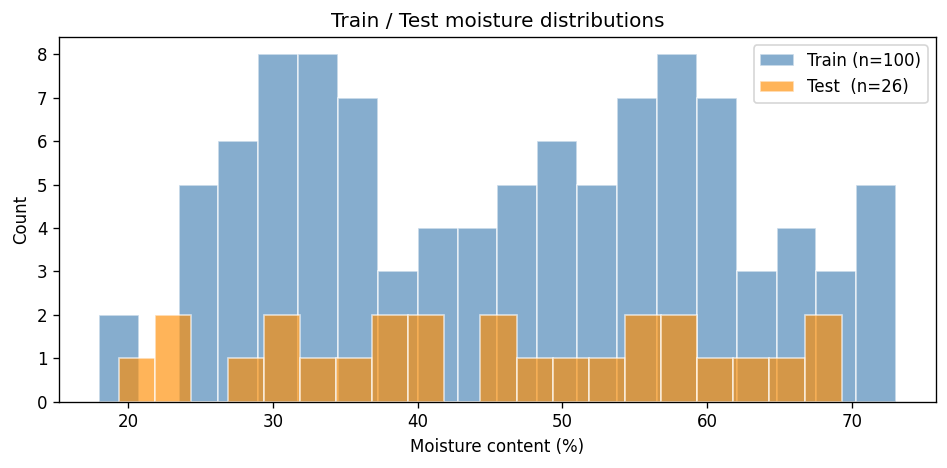

Split distribution plot saved.


In [14]:
# Stratified split based on moisture quantile bins
n_bins    = 5
y_bins    = pd.qcut(y_all, q=n_bins, labels=False)

idx_train, idx_test = train_test_split(
    np.arange(len(y_all)),
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_bins
)

X_train, X_test = X_all[idx_train], X_all[idx_test]
y_train, y_test = y_all[idx_train], y_all[idx_test]

print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)
print(f"  Training samples : {len(y_train)}  ({len(y_train)/len(y_all)*100:.0f}%)")
print(f"  Test samples     : {len(y_test)}   ({len(y_test)/len(y_all)*100:.0f}%)")
print(f"  Train moisture   : {y_train.min():.2f} – {y_train.max():.2f} %  "
      f"(mean {y_train.mean():.2f}%)")
print(f"  Test  moisture   : {y_test.min():.2f} – {y_test.max():.2f} %  "
      f"(mean {y_test.mean():.2f}%)")

# Visual check — moisture distributions
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_train, bins=20, alpha=0.65, color='steelblue',
        edgecolor='white', label=f'Train (n={len(y_train)})')
ax.hist(y_test,  bins=20, alpha=0.65, color='darkorange',
        edgecolor='white', label=f'Test  (n={len(y_test)})')
ax.set_xlabel('Moisture content (%)'); ax.set_ylabel('Count')
ax.set_title('Train / Test moisture distributions')
ax.legend()
plt.tight_layout()
plt.savefig('fig_train_test_split.png', bbox_inches='tight')
plt.show()
print("Split distribution plot saved.")

## 3. Cross-Validation & Evaluation Helpers


In [15]:
N_FOLDS  = 10
group_kf = GroupKFold(n_splits=N_FOLDS)
# Groups: each training sample is its own group (already deduplicated)
groups_train = np.arange(len(y_train))

def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    rpd  = y_true.std() / rmse
    return rmse, r2, rpd

def cv_simple(estimator, X_in, fold_rmses_out=None):
    y_cv = np.zeros_like(y_train)
    folds = []
    for tr, te in group_kf.split(X_in, y_train, groups_train):
        estimator.fit(X_in[tr], y_train[tr])
        pred = estimator.predict(X_in[te]).ravel()
        y_cv[te] = pred
        folds.append(np.sqrt(mean_squared_error(y_train[te], pred)))
    rmsecv = np.sqrt(mean_squared_error(y_train, y_cv))
    return y_cv, rmsecv, np.array(folds)

def cv_scaled(estimator, X_in, fold_rmses_out=None):
    scaler = StandardScaler()
    y_cv   = np.zeros_like(y_train)
    folds  = []
    for tr, te in group_kf.split(X_in, y_train, groups_train):
        Xtr = scaler.fit_transform(X_in[tr])
        Xte = scaler.transform(X_in[te])
        estimator.fit(Xtr, y_train[tr])
        pred = estimator.predict(Xte).ravel()
        y_cv[te] = pred
        folds.append(np.sqrt(mean_squared_error(y_train[te], pred)))
    rmsecv = np.sqrt(mean_squared_error(y_train, y_cv))
    return y_cv, rmsecv, np.array(folds)

print("CV helpers ready. k=10, GroupKFold on training set only.")

CV helpers ready. k=10, GroupKFold on training set only.


## 4. PCA Dimensionality Reduction (for SVR-PCA and ANN-PCA)


PCA fitted on training set only.
  Components to explain 99.9% variance: 6
  X_train_pca shape: (100, 6)
  X_test_pca  shape: (26, 6)


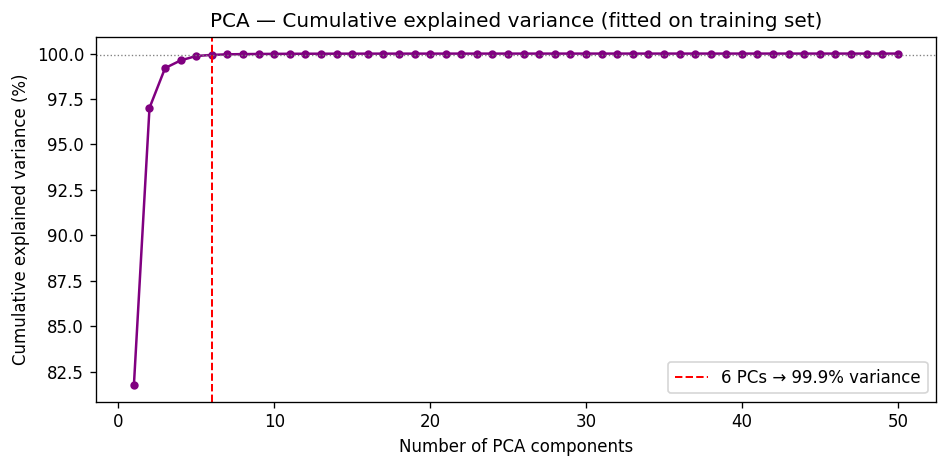

PCA variance plot saved.


In [16]:
scaler_pca = StandardScaler()
X_train_scaled = scaler_pca.fit_transform(X_train)
X_test_scaled  = scaler_pca.transform(X_test)

pca_model = PCA(random_state=RANDOM_STATE)
pca_model.fit(X_train_scaled)
cumvar = np.cumsum(pca_model.explained_variance_ratio_)
n_comp = int(np.searchsorted(cumvar, 0.999)) + 1

X_train_pca = pca_model.transform(X_train_scaled)[:, :n_comp]
X_test_pca  = pca_model.transform(X_test_scaled)[:, :n_comp]

print(f"PCA fitted on training set only.")
print(f"  Components to explain 99.9% variance: {n_comp}")
print(f"  X_train_pca shape: {X_train_pca.shape}")
print(f"  X_test_pca  shape: {X_test_pca.shape}")

# Cumulative variance plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, min(51, len(cumvar)+1)), cumvar[:50]*100,
        'o-', color='purple', linewidth=1.5, markersize=4)
ax.axvline(n_comp, color='red', linestyle='--', linewidth=1.2,
           label=f'{n_comp} PCs → 99.9% variance')
ax.axhline(99.9, color='gray', linestyle=':', linewidth=0.8)
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Cumulative explained variance (%)')
ax.set_title('PCA — Cumulative explained variance (fitted on training set)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_pca_variance.png', bbox_inches='tight')
plt.show()
print("PCA variance plot saved.")

## 5. Model 1 — PLSR (Partial Least Squares Regression)

--- PLSR: tuning number of latent variables (CV on train) ---
  LV=25  RMSECV=2.4241
  Best LVs: 13  (RMSECV=2.1954%)


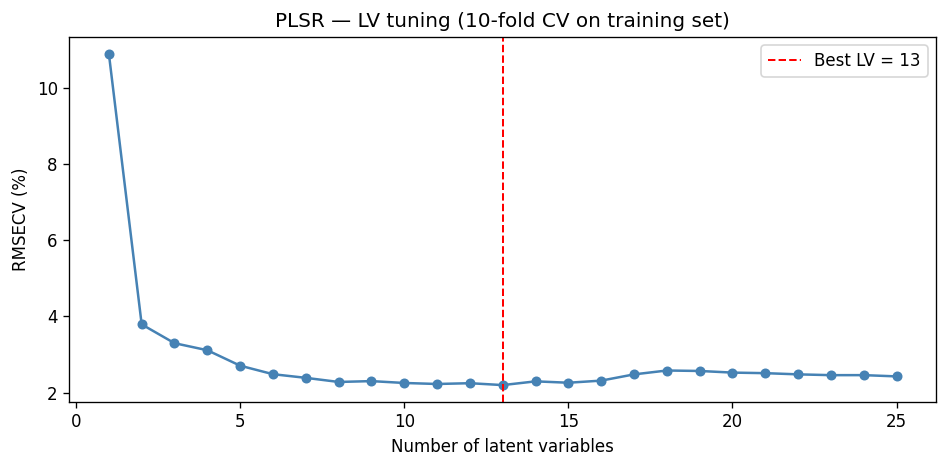


  PLSR Results:
    RMSECV (CV on train) = 2.1954 %
    RMSE   (test set)    = 2.3880 %
    R²     (test set)    = 0.9734
    RPD    (test set)    = 6.1322


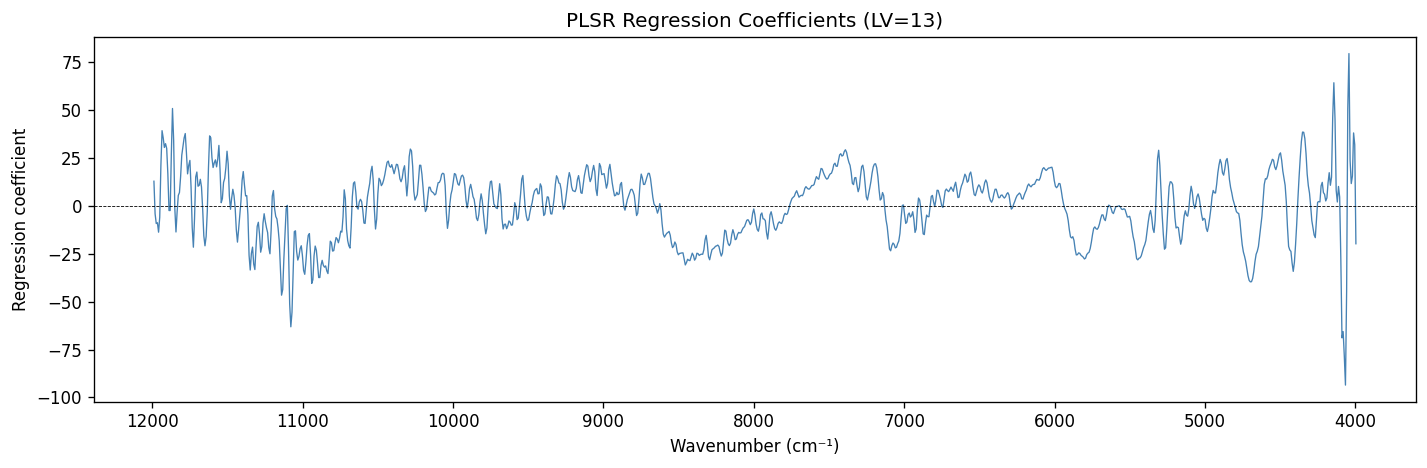

PLSR plots saved.


In [17]:
print("--- PLSR: tuning number of latent variables (CV on train) ---")
lv_range  = range(1, 26)
rmsecv_lv = []
for n_lv in lv_range:
    pls   = PLSRegression(n_components=n_lv, scale=False)
    y_cv  = np.zeros_like(y_train)
    for tr, te in group_kf.split(X_train, y_train, groups_train):
        pls.fit(X_train[tr], y_train[tr])
        y_cv[te] = pls.predict(X_train[te]).ravel()
    rmsecv_lv.append(np.sqrt(mean_squared_error(y_train, y_cv)))
    print(f"  LV={n_lv:2d}  RMSECV={rmsecv_lv[-1]:.4f}", end='\r')

best_lv = int(np.argmin(rmsecv_lv)) + 1
print(f"\n  Best LVs: {best_lv}  (RMSECV={min(rmsecv_lv):.4f}%)")

# LV tuning plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lv_range, rmsecv_lv, 'o-', color='steelblue', linewidth=1.5, markersize=5)
ax.axvline(best_lv, color='red', linestyle='--', linewidth=1.2,
           label=f'Best LV = {best_lv}')
ax.set_xlabel('Number of latent variables'); ax.set_ylabel('RMSECV (%)')
ax.set_title('PLSR — LV tuning (10-fold CV on training set)'); ax.legend()
plt.tight_layout()
plt.savefig('fig_plsr_lv_tuning.png', bbox_inches='tight')
plt.show()

# CV predictions on training set → RMSECV
pls_cv = PLSRegression(n_components=best_lv, scale=False)
y_cv_pls, pls_rmsecv, pls_fm = cv_simple(pls_cv, X_train)

# Refit on full training set → predict test set → RMSE
pls_final = PLSRegression(n_components=best_lv, scale=False)
pls_final.fit(X_train, y_train)
y_test_pls = pls_final.predict(X_test).ravel()
pls_rmse, pls_r2, pls_rpd = evaluate(y_test, y_test_pls)

print(f"\n  PLSR Results:")
print(f"    RMSECV (CV on train) = {pls_rmsecv:.4f} %")
print(f"    RMSE   (test set)    = {pls_rmse:.4f} %")
print(f"    R²     (test set)    = {pls_r2:.4f}")
print(f"    RPD    (test set)    = {pls_rpd:.4f}")

# Regression coefficients
pls_final.fit(X_train, y_train)
beta = pls_final.coef_.ravel()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(wavenumbers, beta, color='steelblue', linewidth=0.8)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_xlabel('Wavenumber (cm⁻¹)'); ax.set_ylabel('Regression coefficient')
ax.set_title(f'PLSR Regression Coefficients (LV={best_lv})')
ax.invert_xaxis()
plt.tight_layout()
plt.savefig('fig_plsr_coefficients.png', bbox_inches='tight')
plt.show()
print("PLSR plots saved.")

## 6. Model 2 — SVR with PCA inputs


In [18]:
print("--- SVR (PCA): grid search on training set ---")
C_values   = [0.1, 1, 10, 50, 100]
eps_values = [0.01, 0.1, 0.5, 1.0]
best_svr_pca_params = {'C': 10, 'epsilon': 0.1}
best_svr_pca_rmsecv = np.inf

for C in C_values:
    for eps in eps_values:
        svr  = SVR(kernel='rbf', C=C, epsilon=eps)
        y_cv = np.zeros_like(y_train)
        for tr, te in group_kf.split(X_train_pca, y_train, groups_train):
            svr.fit(X_train_pca[tr], y_train[tr])
            y_cv[te] = svr.predict(X_train_pca[te])
        rmse_cv = np.sqrt(mean_squared_error(y_train, y_cv))
        if rmse_cv < best_svr_pca_rmsecv:
            best_svr_pca_rmsecv = rmse_cv
            best_svr_pca_params = {'C': C, 'epsilon': eps}

print(f"  Best params : C={best_svr_pca_params['C']}, epsilon={best_svr_pca_params['epsilon']}")
print(f"  RMSECV      : {best_svr_pca_rmsecv:.4f}%")

# CV predictions for fold distribution
svr_pca_cv = SVR(kernel='rbf', C=best_svr_pca_params['C'],
                 epsilon=best_svr_pca_params['epsilon'])
y_cv_svr_pca, svr_pca_rmsecv, svr_pca_fm = cv_simple(svr_pca_cv, X_train_pca)

# Refit on full training set → test set
svr_pca_final = SVR(kernel='rbf', C=best_svr_pca_params['C'],
                    epsilon=best_svr_pca_params['epsilon'])
svr_pca_final.fit(X_train_pca, y_train)
y_test_svr_pca = svr_pca_final.predict(X_test_pca)
svr_pca_rmse, svr_pca_r2, svr_pca_rpd = evaluate(y_test, y_test_svr_pca)

print(f"\n  SVR (PCA) Results:")
print(f"    RMSECV (CV on train) = {svr_pca_rmsecv:.4f} %")
print(f"    RMSE   (test set)    = {svr_pca_rmse:.4f} %")
print(f"    R²     (test set)    = {svr_pca_r2:.4f}")
print(f"    RPD    (test set)    = {svr_pca_rpd:.4f}")

--- SVR (PCA): grid search on training set ---
  Best params : C=100, epsilon=0.01
  RMSECV      : 3.3392%

  SVR (PCA) Results:
    RMSECV (CV on train) = 3.3392 %
    RMSE   (test set)    = 2.2596 %
    R²     (test set)    = 0.9762
    RPD    (test set)    = 6.4808


## 7. Model 3 — SVR with Full Spectrum

In [19]:
print("--- SVR (full spectrum): coarse + fine grid search on training set ---")

def _svr_full_cv(C, eps, gamma):
    scaler = StandardScaler()
    y_cv   = np.zeros_like(y_train)
    folds  = []
    for tr, te in group_kf.split(X_train, y_train, groups_train):
        Xtr = scaler.fit_transform(X_train[tr])
        Xte = scaler.transform(X_train[te])
        svr = SVR(kernel='rbf', C=C, epsilon=eps, gamma=gamma)
        svr.fit(Xtr, y_train[tr])
        pred = svr.predict(Xte)
        y_cv[te] = pred
        folds.append(np.sqrt(mean_squared_error(y_train[te], pred)))
    rmsecv = np.sqrt(mean_squared_error(y_train, y_cv))
    return rmsecv, y_cv, np.array(folds)

# Coarse grid
coarse = {'C': [50, 100, 200, 300, 500],
          'epsilon': [0.1, 0.3, 0.5],
          'gamma':   [0.00005, 0.0001, 0.00015, 0.0002]}
best_svr_full_params = {}
best_svr_full_rmsecv = np.inf

for C in coarse['C']:
    for eps in coarse['epsilon']:
        for gamma in coarse['gamma']:
            r, _, _ = _svr_full_cv(C, eps, gamma)
            if r < best_svr_full_rmsecv:
                best_svr_full_rmsecv = r
                best_svr_full_params = dict(C=C, epsilon=eps, gamma=gamma)

print(f"  Coarse best: {best_svr_full_params}  RMSECV={best_svr_full_rmsecv:.4f}%")

# Fine grid around coarse best
C_b = best_svr_full_params['C']
e_b = best_svr_full_params['epsilon']
g_b = best_svr_full_params['gamma']
fine = {'C':       [C_b*0.5, C_b*0.75, C_b, C_b*1.25, C_b*1.5],
        'epsilon': [max(0.05, e_b-0.1), e_b, e_b+0.1],
        'gamma':   [g_b*0.5, g_b*0.75, g_b, g_b*1.25, g_b*1.5]}

for C in fine['C']:
    for eps in fine['epsilon']:
        for gamma in fine['gamma']:
            r, _, _ = _svr_full_cv(C, eps, gamma)
            if r < best_svr_full_rmsecv:
                best_svr_full_rmsecv = r
                best_svr_full_params = dict(C=C, epsilon=eps, gamma=gamma)

print(f"  Fine best  : {best_svr_full_params}  RMSECV={best_svr_full_rmsecv:.4f}%")

# CV fold distribution with best params
svr_full_rmsecv, y_cv_svr_full, svr_full_fm = _svr_full_cv(
    best_svr_full_params['C'],
    best_svr_full_params['epsilon'],
    best_svr_full_params['gamma'])

# Refit on full training set → test set
scaler_svr_full = StandardScaler()
X_train_sf = scaler_svr_full.fit_transform(X_train)
X_test_sf  = scaler_svr_full.transform(X_test)
svr_full_final = SVR(kernel='rbf', C=best_svr_full_params['C'],
                     epsilon=best_svr_full_params['epsilon'],
                     gamma=best_svr_full_params['gamma'])
svr_full_final.fit(X_train_sf, y_train)
y_test_svr_full = svr_full_final.predict(X_test_sf)
svr_full_rmse, svr_full_r2, svr_full_rpd = evaluate(y_test, y_test_svr_full)

print(f"\n  SVR (Full) Results:")
print(f"    RMSECV (CV on train) = {svr_full_rmsecv:.4f} %")
print(f"    RMSE   (test set)    = {svr_full_rmse:.4f} %")
print(f"    R²     (test set)    = {svr_full_r2:.4f}")
print(f"    RPD    (test set)    = {svr_full_rpd:.4f}")

--- SVR (full spectrum): coarse + fine grid search on training set ---
  Coarse best: {'C': 500, 'epsilon': 0.5, 'gamma': 0.0002}  RMSECV=2.8358%
  Fine best  : {'C': 750.0, 'epsilon': 0.5, 'gamma': 0.00025}  RMSECV=2.5886%

  SVR (Full) Results:
    RMSECV (CV on train) = 2.5886 %
    RMSE   (test set)    = 2.0499 %
    R²     (test set)    = 0.9804
    RPD    (test set)    = 7.1438


## 8. Model 4 — ANN with PCA inputs

In [20]:
print("--- ANN (PCA): tuning hidden layer size (CV on train) ---")
hidden_sizes = [10, 20, 30, 50]
best_ann_pca_size  = 30
best_ann_pca_rmsecv = np.inf

for hs in hidden_sizes:
    ann  = MLPRegressor(hidden_layer_sizes=(hs,), activation='relu',
                        solver='lbfgs', alpha=0.01,
                        max_iter=5000, random_state=RANDOM_STATE)
    _, rmsecv, _ = cv_scaled(ann, X_train_pca)
    print(f"  Hidden={hs:3d}  RMSECV={rmsecv:.4f}%")
    if rmsecv < best_ann_pca_rmsecv:
        best_ann_pca_rmsecv = rmsecv
        best_ann_pca_size   = hs

print(f"\n  Best hidden size: {best_ann_pca_size}  (RMSECV={best_ann_pca_rmsecv:.4f}%)")

# CV fold distribution with best size
ann_pca_cv = MLPRegressor(hidden_layer_sizes=(best_ann_pca_size,), activation='relu',
                           solver='lbfgs', alpha=0.01,
                           max_iter=5000, random_state=RANDOM_STATE)
y_cv_ann_pca, ann_pca_rmsecv, ann_pca_fm = cv_scaled(ann_pca_cv, X_train_pca)

# Refit on full training set → test set
scaler_ann_pca = StandardScaler()
X_train_ap = scaler_ann_pca.fit_transform(X_train_pca)
X_test_ap  = scaler_ann_pca.transform(X_test_pca)
ann_pca_final = MLPRegressor(hidden_layer_sizes=(best_ann_pca_size,), activation='relu',
                              solver='lbfgs', alpha=0.01,
                              max_iter=5000, random_state=RANDOM_STATE)
ann_pca_final.fit(X_train_ap, y_train)
y_test_ann_pca = ann_pca_final.predict(X_test_ap)
ann_pca_rmse, ann_pca_r2, ann_pca_rpd = evaluate(y_test, y_test_ann_pca)

print(f"\n  ANN (PCA) Results:")
print(f"    RMSECV (CV on train) = {ann_pca_rmsecv:.4f} %")
print(f"    RMSE   (test set)    = {ann_pca_rmse:.4f} %")
print(f"    R²     (test set)    = {ann_pca_r2:.4f}")
print(f"    RPD    (test set)    = {ann_pca_rpd:.4f}")

--- ANN (PCA): tuning hidden layer size (CV on train) ---
  Hidden= 10  RMSECV=5.0204%
  Hidden= 20  RMSECV=5.8549%
  Hidden= 30  RMSECV=4.9107%
  Hidden= 50  RMSECV=6.4582%

  Best hidden size: 30  (RMSECV=4.9107%)

  ANN (PCA) Results:
    RMSECV (CV on train) = 4.9107 %
    RMSE   (test set)    = 3.0542 %
    R²     (test set)    = 0.9565
    RPD    (test set)    = 4.7947


## 9. Model 5 — ANN with Full Spectrum


In [21]:
print("--- ANN (full spectrum): hidden=(30,) relu alpha=0.01 adam ---")
print(f"  PCA:  45×30 =  1,350 weights  /  {len(y_train)} training samples  → feasible")
print(f"  Full: 1037×30 = 31,110 weights  /  {len(y_train)} training samples  → over-parameterised")
print(f"  lbfgs infeasible on 1037 inputs — using adam\n")

ann_full_cv = MLPRegressor(hidden_layer_sizes=(30,), activation='relu',
                            solver='adam', alpha=0.01,
                            max_iter=2000, random_state=RANDOM_STATE)
y_cv_ann_full, ann_full_rmsecv, ann_full_fm = cv_scaled(ann_full_cv, X_train)

# Refit on full training set → test set
scaler_ann_full = StandardScaler()
X_train_af = scaler_ann_full.fit_transform(X_train)
X_test_af  = scaler_ann_full.transform(X_test)
ann_full_final = MLPRegressor(hidden_layer_sizes=(30,), activation='relu',
                               solver='adam', alpha=0.01,
                               max_iter=2000, random_state=RANDOM_STATE)
ann_full_final.fit(X_train_af, y_train)
y_test_ann_full = ann_full_final.predict(X_test_af)
ann_full_rmse, ann_full_r2, ann_full_rpd = evaluate(y_test, y_test_ann_full)

print(f"  ANN (Full) Results:")
print(f"    RMSECV (CV on train) = {ann_full_rmsecv:.4f} %")
print(f"    RMSE   (test set)    = {ann_full_rmse:.4f} %")
print(f"    R²     (test set)    = {ann_full_r2:.4f}")
print(f"    RPD    (test set)    = {ann_full_rpd:.4f}")

--- ANN (full spectrum): hidden=(30,) relu alpha=0.01 adam ---
  PCA:  45×30 =  1,350 weights  /  100 training samples  → feasible
  Full: 1037×30 = 31,110 weights  /  100 training samples  → over-parameterised
  lbfgs infeasible on 1037 inputs — using adam

  ANN (Full) Results:
    RMSECV (CV on train) = 11.3941 %
    RMSE   (test set)    = 9.9540 %
    R²     (test set)    = 0.5380
    RPD    (test set)    = 1.4712


## 10. Results Comparison


In [22]:
# ── Assemble results dict ─────────────────────────────────────────────────────
models = {
    'PLSR': {
        'rmsecv': pls_rmsecv,   'rmse': pls_rmse,
        'r2': pls_r2,           'rpd': pls_rpd,
        'y_cv': y_cv_pls,       'y_test': y_test_pls,
        'fm': pls_fm,           'color': 'steelblue',
        'input': 'Full spectrum (1037)'
    },
    'SVR — PCA': {
        'rmsecv': svr_pca_rmsecv,  'rmse': svr_pca_rmse,
        'r2': svr_pca_r2,          'rpd': svr_pca_rpd,
        'y_cv': y_cv_svr_pca,      'y_test': y_test_svr_pca,
        'fm': svr_pca_fm,          'color': 'darkorange',
        'input': 'PCA (45 components)'
    },
    'SVR — Full': {
        'rmsecv': svr_full_rmsecv, 'rmse': svr_full_rmse,
        'r2': svr_full_r2,         'rpd': svr_full_rpd,
        'y_cv': y_cv_svr_full,     'y_test': y_test_svr_full,
        'fm': svr_full_fm,         'color': 'tomato',
        'input': 'Full spectrum (1037)'
    },
    'ANN — PCA': {
        'rmsecv': ann_pca_rmsecv,  'rmse': ann_pca_rmse,
        'r2': ann_pca_r2,          'rpd': ann_pca_rpd,
        'y_cv': y_cv_ann_pca,      'y_test': y_test_ann_pca,
        'fm': ann_pca_fm,          'color': 'mediumseagreen',
        'input': 'PCA (45 components)'
    },
    'ANN — Full': {
        'rmsecv': ann_full_rmsecv, 'rmse': ann_full_rmse,
        'r2': ann_full_r2,         'rpd': ann_full_rpd,
        'y_cv': y_cv_ann_full,     'y_test': y_test_ann_full,
        'fm': ann_full_fm,         'color': 'mediumpurple',
        'input': 'Full spectrum (1037)'
    },
}

# ── Printed table ──────────────────────────────────────────────────────────────
print("=" * 80)
print("5-MODEL COMPARISON  |  Training CV (n=101) + Independent Test (n=25)")
print("=" * 80)
print(f"  {'Model':<18} {'Input':<24} {'RMSECV':>8}  {'RMSE':>8}  {'R²':>7}  {'RPD':>7}")
print(f"  {'-'*76}")
for name, m in sorted(models.items(), key=lambda x: x[1]['rmse']):
    print(f"  {name:<18} {m['input']:<24} {m['rmsecv']:>8.4f}  "
          f"{m['rmse']:>8.4f}  {m['r2']:>7.4f}  {m['rpd']:>7.4f}")

best = min(models, key=lambda k: models[k]['rmse'])
print(f"\n  ★ Best model (test RMSE): {best}  "
      f"(RMSE={models[best]['rmse']:.4f}%  R²={models[best]['r2']:.4f}  "
      f"RPD={models[best]['rpd']:.4f})")
print("\n  RPD: >5 excellent  |  3–5 good  |  2–3 moderate  |  <2 poor")

5-MODEL COMPARISON  |  Training CV (n=101) + Independent Test (n=25)
  Model              Input                      RMSECV      RMSE       R²      RPD
  ----------------------------------------------------------------------------
  SVR — Full         Full spectrum (1037)       2.5886    2.0499   0.9804   7.1438
  SVR — PCA          PCA (45 components)        3.3392    2.2596   0.9762   6.4808
  PLSR               Full spectrum (1037)       2.1954    2.3880   0.9734   6.1322
  ANN — PCA          PCA (45 components)        4.9107    3.0542   0.9565   4.7947
  ANN — Full         Full spectrum (1037)      11.3941    9.9540   0.5380   1.4712

  ★ Best model (test RMSE): SVR — Full  (RMSE=2.0499%  R²=0.9804  RPD=7.1438)

  RPD: >5 excellent  |  3–5 good  |  2–3 moderate  |  <2 poor


### 10.1 Parity Plots — Test Set Predictions

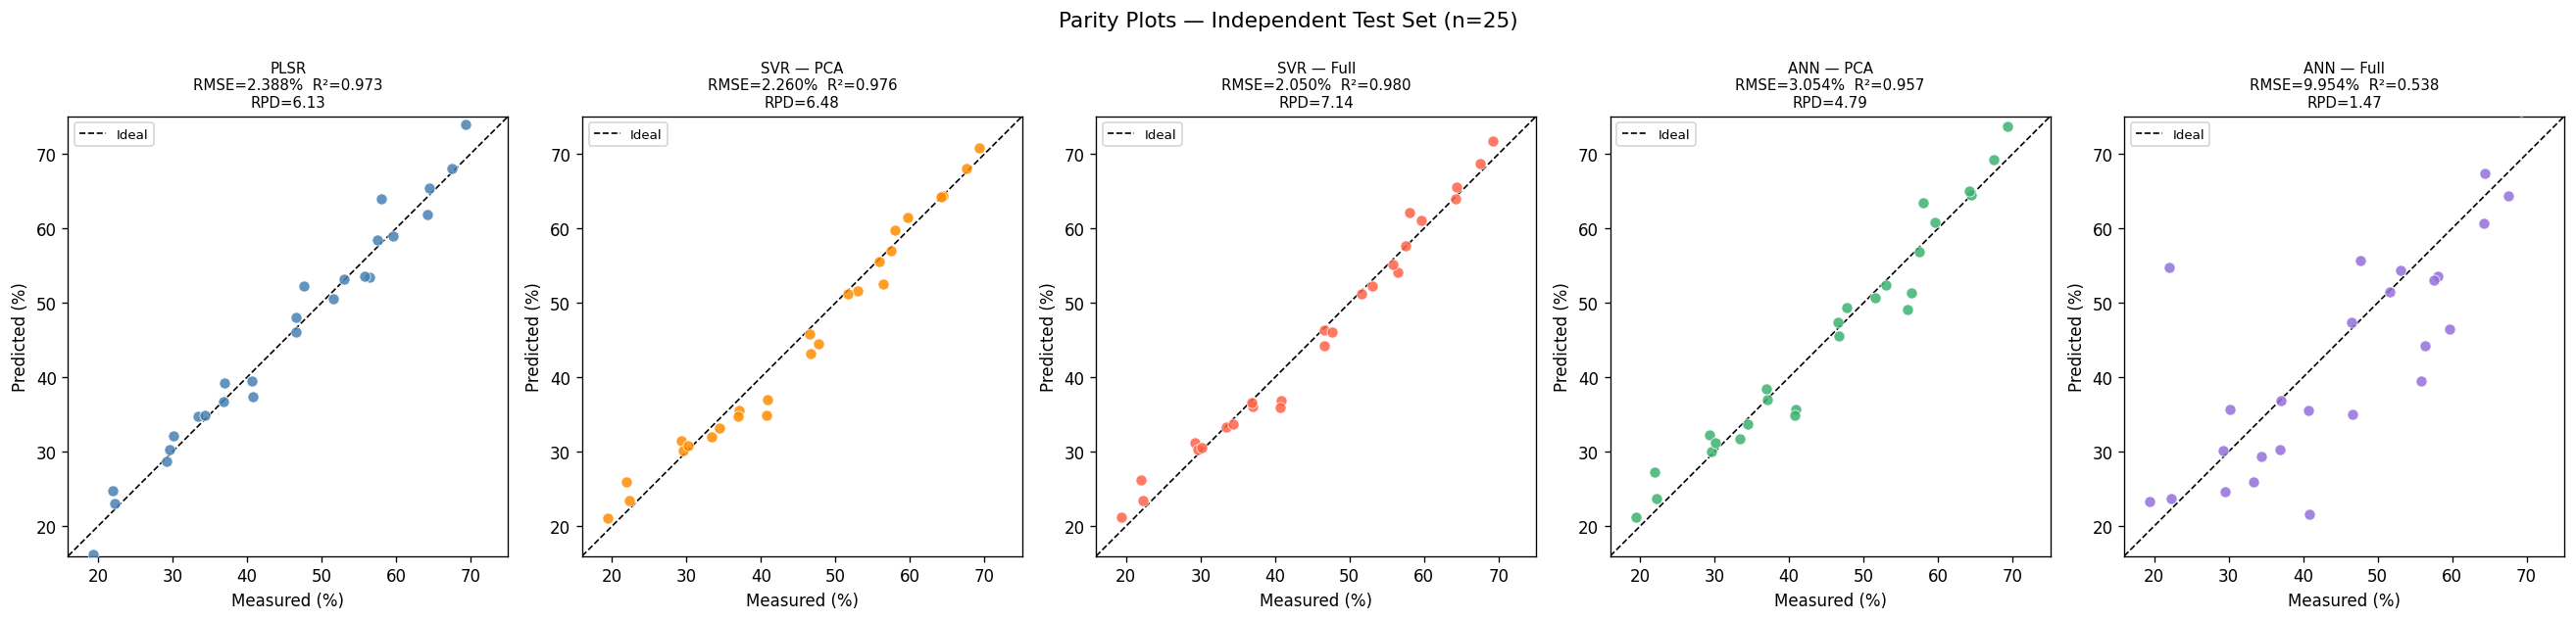

Test set parity plots saved.


In [23]:
lims = [y_all.min() - 2, y_all.max() + 2]
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, (name, m) in zip(axes, models.items()):
    ax.scatter(y_test, m['y_test'], alpha=0.85, s=45,
               color=m['color'], edgecolors='white', linewidth=0.5, zorder=3)
    ax.plot(lims, lims, 'k--', linewidth=1, label='Ideal')
    ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect('equal')
    ax.set_xlabel('Measured (%)'); ax.set_ylabel('Predicted (%)')
    ax.set_title(f'{name}\nRMSE={m["rmse"]:.3f}%  R²={m["r2"]:.3f}\nRPD={m["rpd"]:.2f}',
                 fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle('Parity Plots — Independent Test Set (n=25)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_parity_test_all5.png', bbox_inches='tight', dpi=130)
plt.show()
print("Test set parity plots saved.")

### 10.2 Metric Bar Charts — RMSECV, RMSE, R², RPD

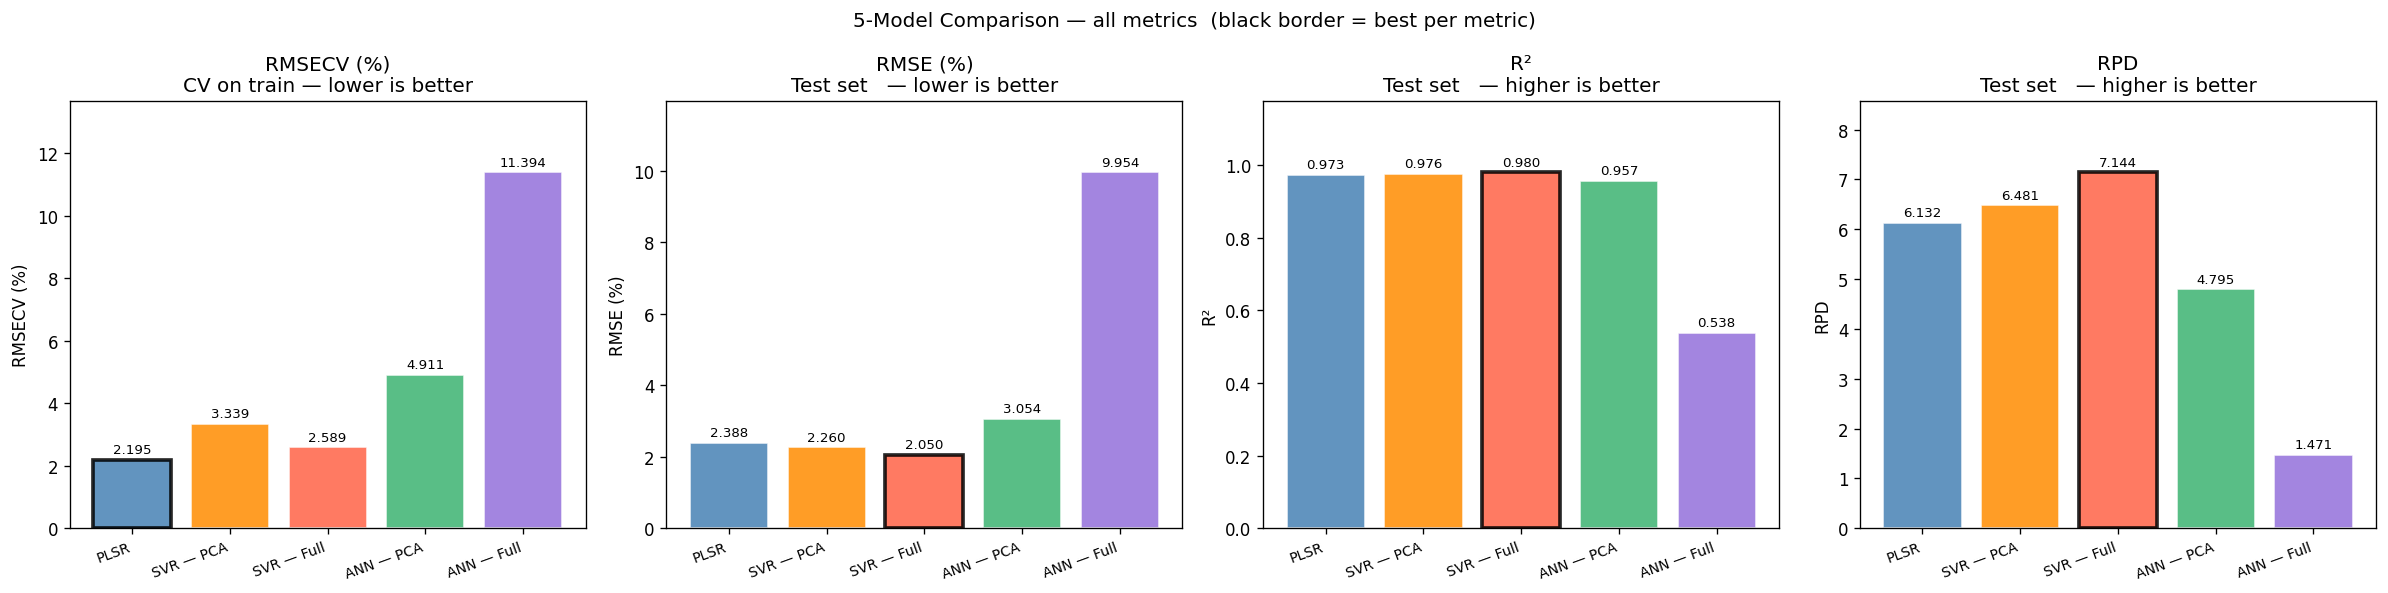

Metric bar charts saved.


In [24]:
names  = list(models.keys())
colors = [m['color'] for m in models.values()]

metrics_to_plot = [
    ('RMSECV (%)',  [m['rmsecv'] for m in models.values()], 'CV on train — lower is better',  True),
    ('RMSE (%)',    [m['rmse']   for m in models.values()], 'Test set   — lower is better',   True),
    ('R²',          [m['r2']     for m in models.values()], 'Test set   — higher is better',  False),
    ('RPD',         [m['rpd']    for m in models.values()], 'Test set   — higher is better',  False),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (label, vals, note, lower_better) in zip(axes, metrics_to_plot):
    bars = ax.bar(names, vals, color=colors, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                v + max(vals)*0.01, f'{v:.3f}',
                ha='center', va='bottom', fontsize=8)
    ax.set_ylabel(label); ax.set_title(f'{label}\n{note}')
    ax.set_ylim(0, max(vals) * 1.20)
    ax.set_xticklabels(names, rotation=20, ha='right', fontsize=8.5)
    # Bold border on best bar
    best_idx = int(np.argmin(vals)) if lower_better else int(np.argmax(vals))
    bars[best_idx].set_edgecolor('black'); bars[best_idx].set_linewidth(2.2)

plt.suptitle('5-Model Comparison — all metrics  (black border = best per metric)', fontsize=12)
plt.tight_layout()
plt.savefig('fig_metrics_all5.png', bbox_inches='tight', dpi=130)
plt.show()
print("Metric bar charts saved.")

### 10.3 RMSECV vs RMSE — Overfitting Check


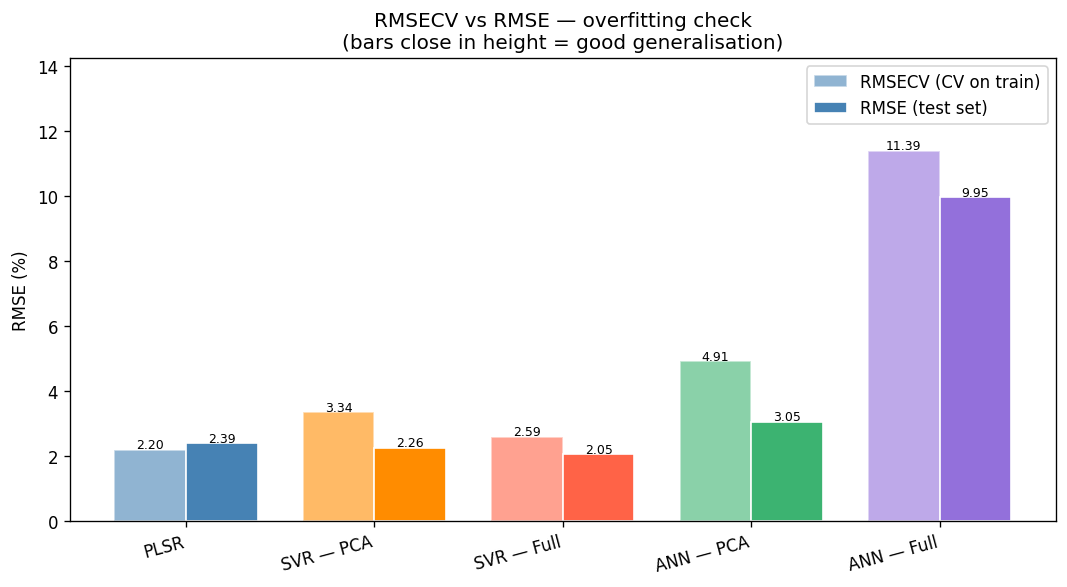

RMSECV vs RMSE plot saved.


In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
x      = np.arange(len(models))
width  = 0.38

rmsecvs = [m['rmsecv'] for m in models.values()]
rmses   = [m['rmse']   for m in models.values()]

b1 = ax.bar(x - width/2, rmsecvs, width, label='RMSECV (CV on train)',
            color=[m['color'] for m in models.values()], alpha=0.6, edgecolor='white')
b2 = ax.bar(x + width/2, rmses,   width, label='RMSE (test set)',
            color=[m['color'] for m in models.values()], alpha=1.0, edgecolor='white')

for bar, v in zip(list(b1)+list(b2), rmsecvs+rmses):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.05,
            f'{v:.2f}', ha='center', fontsize=7.5)

ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('RMSE (%)')
ax.set_title('RMSECV vs RMSE — overfitting check\n'
             '(bars close in height = good generalisation)')
ax.legend(); ax.set_ylim(0, max(rmsecvs + rmses) * 1.25)
plt.tight_layout()
plt.savefig('fig_rmsecv_vs_rmse.png', bbox_inches='tight', dpi=130)
plt.show()
print("RMSECV vs RMSE plot saved.")

### 10.4 Per-fold RMSE Distribution (CV on Training Set)

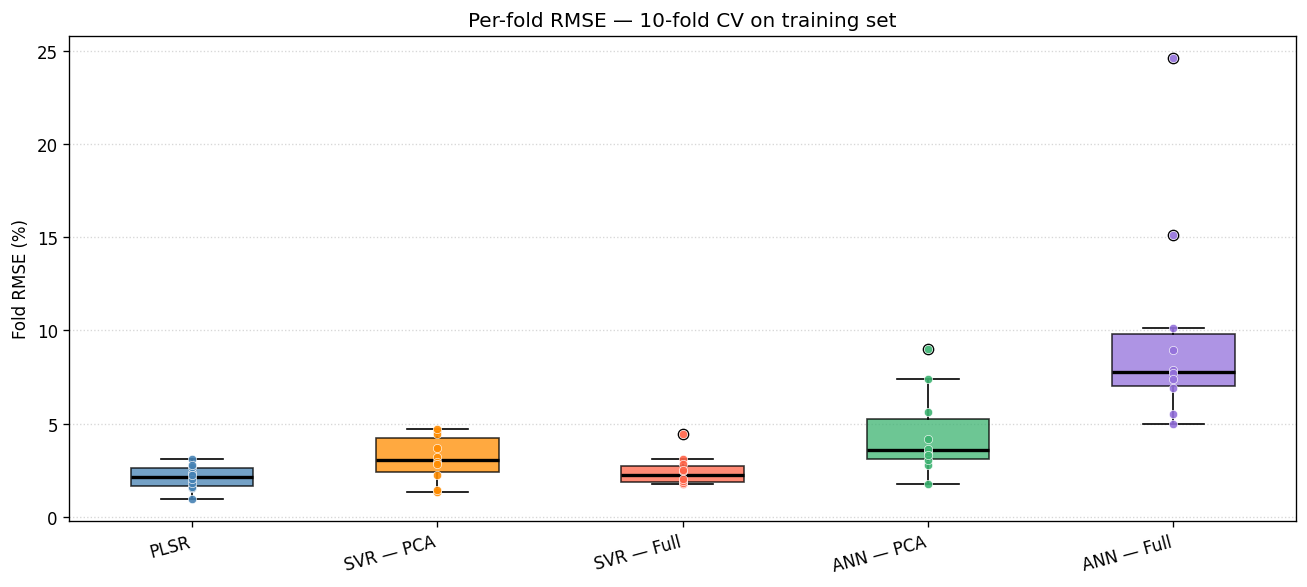

Box plot saved.


In [26]:
fig, ax = plt.subplots(figsize=(11, 5))
fold_data = [m['fm'] for m in models.values()]
bp = ax.boxplot(fold_data, patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
for i, (vals, color) in enumerate(zip(fold_data, colors), 1):
    ax.scatter([i]*len(vals), vals, color=color, s=25,
               edgecolors='white', linewidth=0.4, zorder=3, alpha=0.9)
ax.set_xticks(range(1, 6)); ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Fold RMSE (%)')
ax.set_title('Per-fold RMSE — 10-fold CV on training set')
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('fig_boxplot_folds.png', bbox_inches='tight', dpi=130)
plt.show()
print("Box plot saved.")

### 10.5 Residual Plots — Test Set

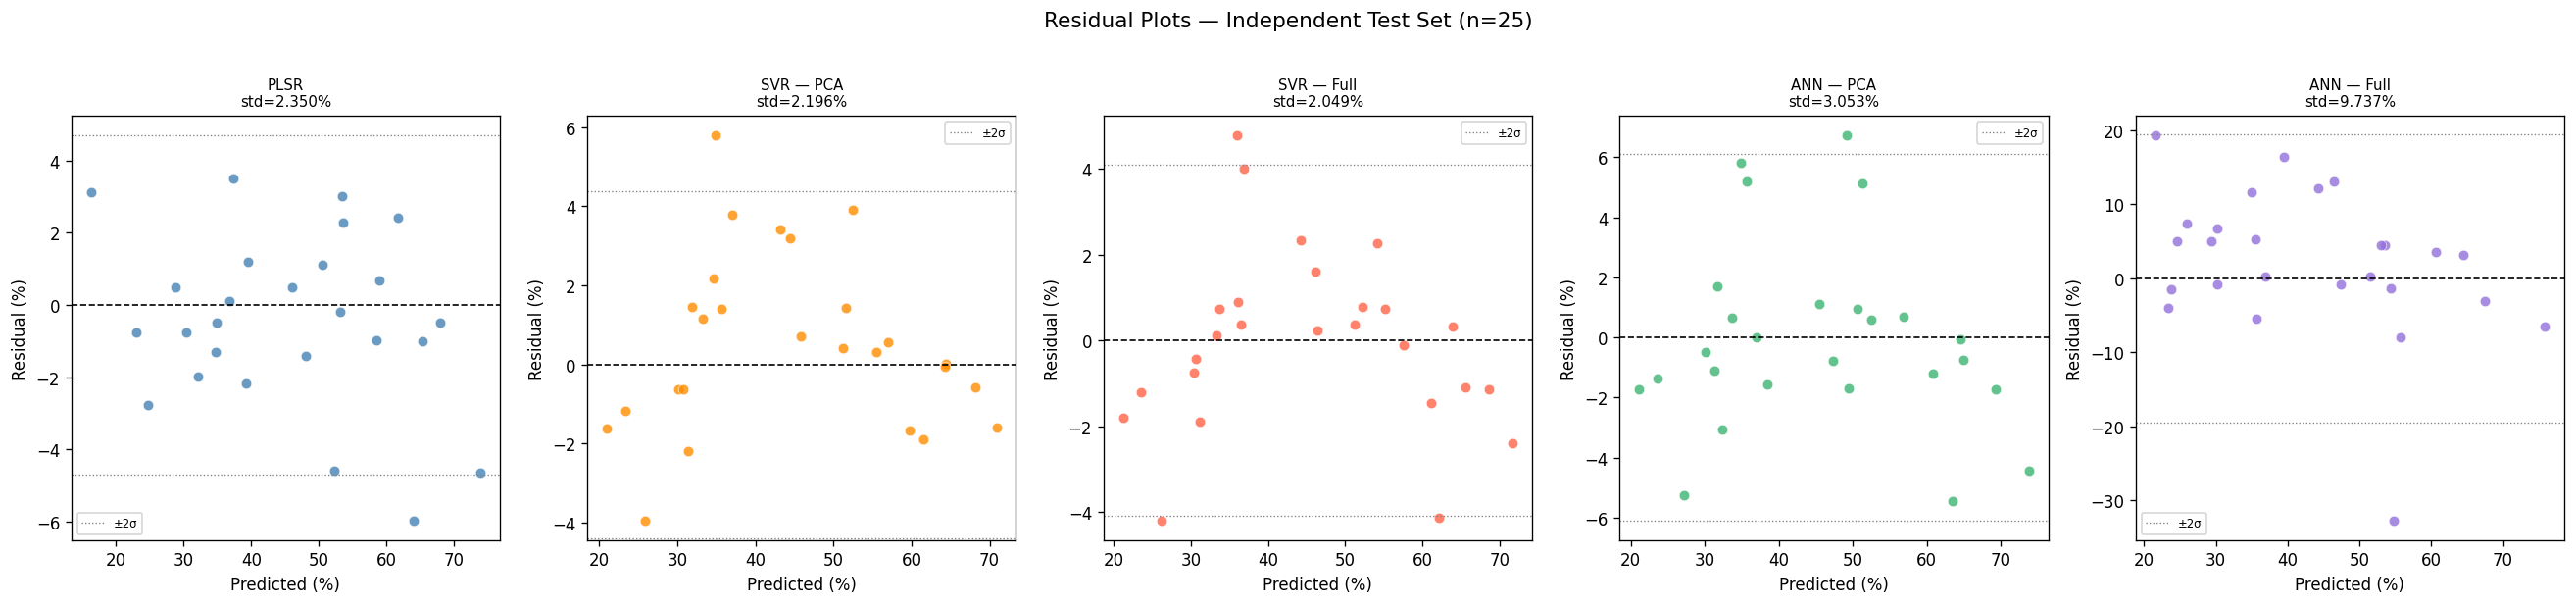

Residual plots saved.


In [27]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, (name, m) in zip(axes, models.items()):
    res = y_test - m['y_test']
    ax.scatter(m['y_test'], res, alpha=0.8, s=40,
               color=m['color'], edgecolors='white', linewidth=0.4)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.axhline( 2*res.std(), color='gray', linewidth=0.8, linestyle=':', label='±2σ')
    ax.axhline(-2*res.std(), color='gray', linewidth=0.8, linestyle=':')
    ax.set_xlabel('Predicted (%)'); ax.set_ylabel('Residual (%)')
    ax.set_title(f'{name}\nstd={res.std():.3f}%', fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle('Residual Plots — Independent Test Set (n=25)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_residuals_test.png', bbox_inches='tight', dpi=130)
plt.show()
print("Residual plots saved.")

### 10.6 Residual Plots — Test Set

## 11. Save Results

In [28]:
results_df = pd.DataFrame([
    {
        'Model':       name,
        'Input':       m['input'],
        'RMSECV (%)':  round(m['rmsecv'], 4),
        'RMSE (%)':    round(m['rmse'],   4),
        'R²':          round(m['r2'],     4),
        'RPD':         round(m['rpd'],    4),
    }
    for name, m in models.items()
]).sort_values('RMSE (%)').reset_index(drop=True)

print(results_df.to_string(index=False))
results_df.to_csv('task2_3_results_final.csv', index=False)
print("\nResults saved to task2_3_results_final.csv")

     Model                Input  RMSECV (%)  RMSE (%)     R²    RPD
SVR — Full Full spectrum (1037)      2.5886    2.0499 0.9804 7.1438
 SVR — PCA  PCA (45 components)      3.3392    2.2596 0.9762 6.4808
      PLSR Full spectrum (1037)      2.1954    2.3880 0.9734 6.1322
 ANN — PCA  PCA (45 components)      4.9107    3.0542 0.9565 4.7947
ANN — Full Full spectrum (1037)     11.3941    9.9540 0.5380 1.4712

Results saved to task2_3_results_final.csv
